## CW - EW


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy.optimize import minimize
import statsmodels.api as sm



In [2]:
# Load returns from WRDS-derived CSVs
crsp_returns = pd.read_csv("sp500_returns_with_tickers.csv", index_col="date", parse_dates=True)
crsp_caps = pd.read_csv("sp500_market_caps.csv", index_col="date", parse_dates=True)


# Scale market caps (convert to actual $)
crsp_caps = crsp_caps * 1000

# Clean numeric
caps_numeric = crsp_caps.apply(pd.to_numeric, errors='coerce').fillna(0)
rets_numeric = crsp_returns.apply(pd.to_numeric, errors='coerce').fillna(0)

# Align columns
common_cols = caps_numeric.columns.intersection(rets_numeric.columns)
caps_numeric = caps_numeric[common_cols]
rets_numeric = rets_numeric[common_cols]

# Cap-weighted
cap_weights = caps_numeric.div(caps_numeric.sum(axis=1), axis=0)
ret_cap = (rets_numeric * cap_weights).sum(axis=1)

# Equal-weighted
active_mask = caps_numeric > 0
n_active = active_mask.sum(axis=1)
equal_weights = active_mask.div(n_active, axis=0)
ret_eq = (rets_numeric * equal_weights).sum(axis=1)

# Preference Portfolio (CRSP-based)
preference_returns = ret_cap - ret_eq
preference_returns.name = "Preference Portfolio (CW-EW)"




In [3]:
returns_df = pd.DataFrame({
    "Cap-Weighted": ret_cap,
    "Equal-Weighted": ret_eq,
    "Preference Portfolio (CW-EW)": preference_returns
})

# Set rolling window size (e.g., 36 months)
window = 36

# Rolling volatility (annualized)
rolling_vol_1 = returns_df.rolling(window).std() * np.sqrt(12)

# Rolling Sharpe Ratio (assumes risk-free rate ~ 0)
rolling_sharpe_1 = returns_df.rolling(window).mean() / returns_df.rolling(window).std() * np.sqrt(12)

# Cumulative log returns
cumulative_returns_1 = np.log1p(returns_df).cumsum()


In [4]:
returns_df

,Cap-Weighted,Equal-Weighted,Preference Portfolio (CW-EW)
date,,,
1960-01-29,-0.067093,-0.049087,-0.018005
1960-02-29,0.017111,0.007490,0.009621
1960-03-31,-0.010623,-0.025784,0.015161
1960-04-29,-0.013724,-0.015902,0.002178
1960-05-31,0.037913,0.025842,0.012071
...,...,...,...
2024-08-30,0.028116,0.024943,0.003173
2024-09-30,0.025856,0.023297,0.002560
2024-10-31,-0.004786,-0.016410,0.011624


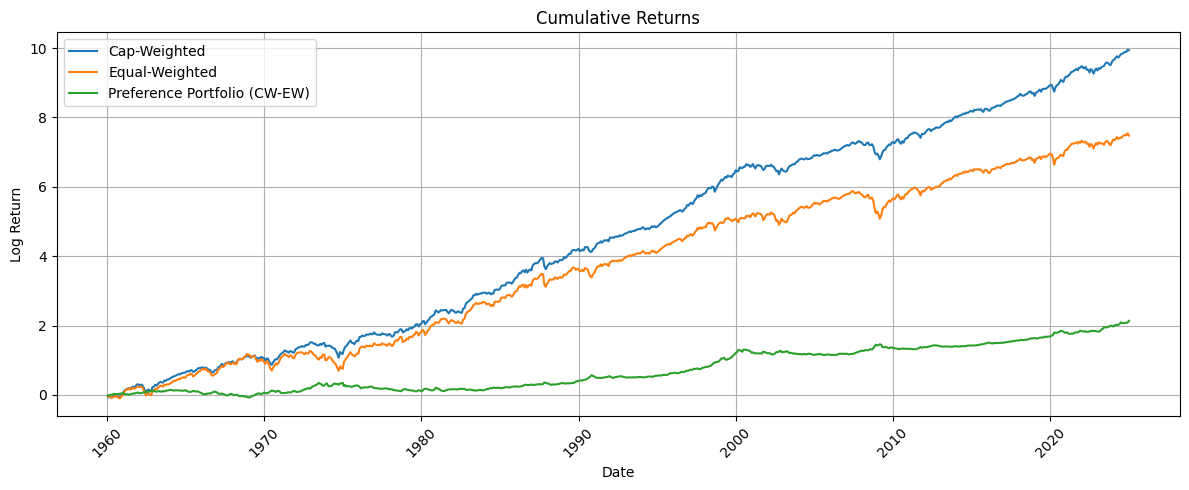

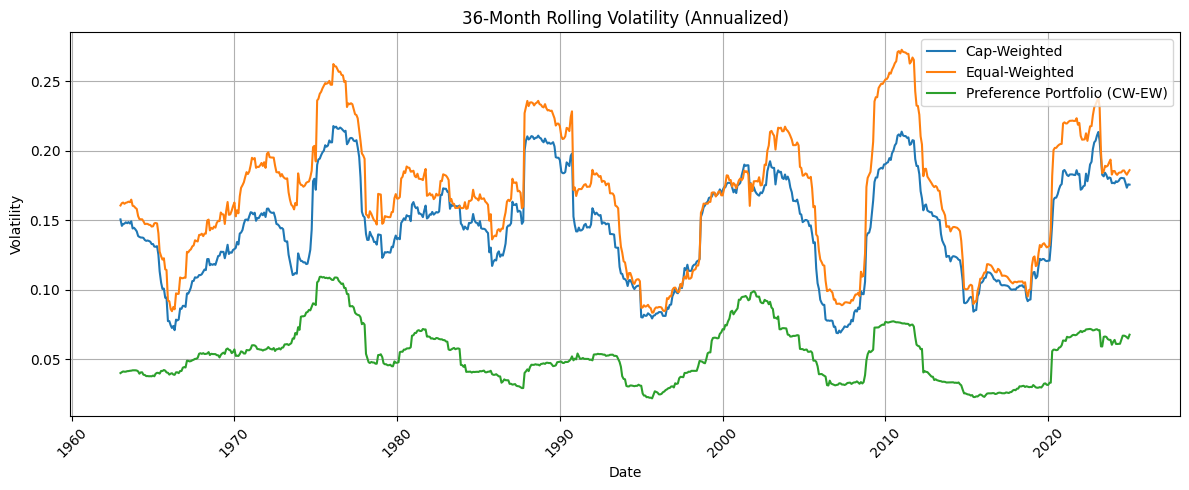

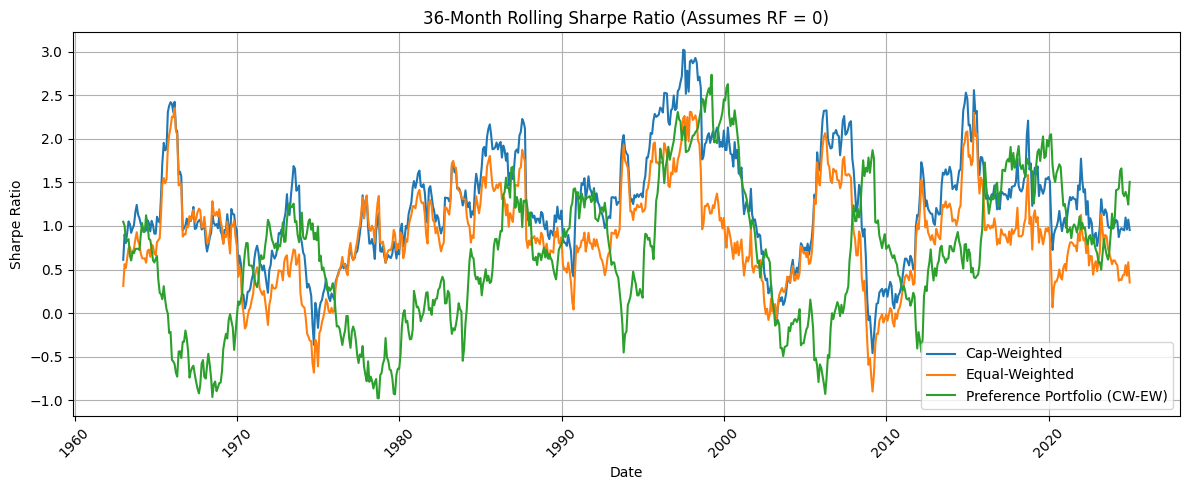

In [5]:
# === Cumulative Returns ===
plt.figure(figsize=(12, 5))
plt.plot(cumulative_returns_1)
plt.title("Cumulative Returns")
plt.ylabel("Log Return")
plt.xlabel("Date")
plt.legend(cumulative_returns_1.columns)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# === Rolling Volatility ===
plt.figure(figsize=(12, 5))
plt.plot(rolling_vol_1)
plt.title(f"{window}-Month Rolling Volatility (Annualized)")
plt.ylabel("Volatility")
plt.xlabel("Date")
plt.legend(rolling_vol_1.columns)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# === Rolling Sharpe Ratio ===
plt.figure(figsize=(12, 5))
plt.plot(rolling_sharpe_1)
plt.title(f"{window}-Month Rolling Sharpe Ratio (Assumes RF = 0)")
plt.ylabel("Sharpe Ratio")
plt.xlabel("Date")
plt.legend(rolling_sharpe_1.columns)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 1/ β

In [6]:
rets = rets_numeric.copy()
market_ret = ret_cap.copy()
window = 36 

In [7]:
#  Estimate rolling beta for each stock
betas = pd.DataFrame(index=rets.index, columns=rets.columns)

for ticker in rets.columns:
    for i in range(window, len(rets)):
        y = rets[ticker].iloc[i-window:i]
        x = market_ret.iloc[i-window:i]
        if y.isnull().any() or x.isnull().any():
            continue
        x_named = x.rename("x")
        X = sm.add_constant(x_named)
        model = sm.OLS(y, X).fit()
        betas.iloc[i, betas.columns.get_loc(ticker)] = model.params["x"]

betas = betas.astype(float)

# Compute inverse-beta weights
#inv_beta_weights = 1 / betas
inv_beta_weights = 1 / betas.abs()
inv_beta_weights.replace([np.inf, -np.inf], np.nan, inplace=True)
inv_beta_weights = inv_beta_weights.div(inv_beta_weights.sum(axis=1), axis=0)

# Compute 1/Beta portfolio return
one_over_beta_return = (rets * inv_beta_weights).sum(axis=1)
one_over_beta_return.name = "1/Beta Portfolio"

# Compute preference portfolio (Cap - 1/Beta)
ret_pref_invbeta = ret_cap - one_over_beta_return
ret_pref_invbeta.name = "Preference (Cap - 1/Beta)"


In [8]:
returns_df["1/Beta"] = one_over_beta_return
returns_df["Preference (Cap - 1/Beta)"] = ret_pref_invbeta

In [9]:
returns_df

,Cap-Weighted,Equal-Weighted,Preference Portfolio (CW-EW),1/Beta,Preference (Cap - 1/Beta)
date,,,,,
1960-01-29,-0.067093,-0.049087,-0.018005,0.000000,-0.067093
1960-02-29,0.017111,0.007490,0.009621,0.000000,0.017111
1960-03-31,-0.010623,-0.025784,0.015161,0.000000,-0.010623
1960-04-29,-0.013724,-0.015902,0.002178,0.000000,-0.013724
1960-05-31,0.037913,0.025842,0.012071,0.000000,0.037913
...,...,...,...,...,...
2024-08-30,0.028116,0.024943,0.003173,0.045284,-0.017168
2024-09-30,0.025856,0.023297,0.002560,0.009644,0.016212
2024-10-31,-0.004786,-0.016410,0.011624,-0.028102,0.023316


In [10]:
returns_df[["1/Beta", "Preference (Cap - 1/Beta)"]].to_csv("inverse_beta_returns.csv", index=True)

In [11]:
returns_invb = returns_df[["Cap-Weighted", "1/Beta", "Preference (Cap - 1/Beta)"]]

In [12]:
rolling_vol = returns_invb.rolling(window).std() * np.sqrt(12)
rolling_sharpe = returns_invb.rolling(window).mean() / returns_invb.rolling(window).std() * np.sqrt(12)
cumulative_returns = np.log1p(returns_invb).cumsum()


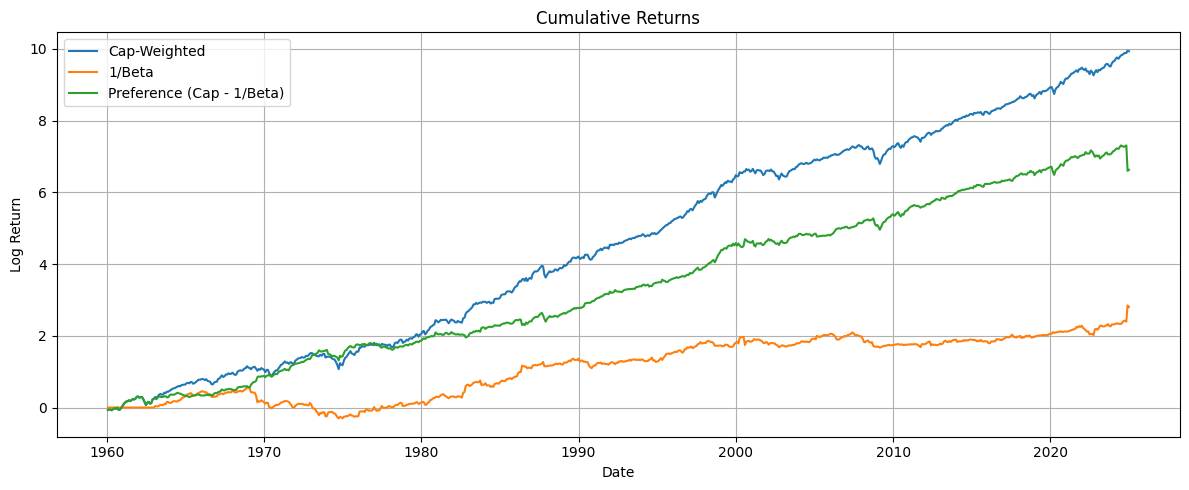

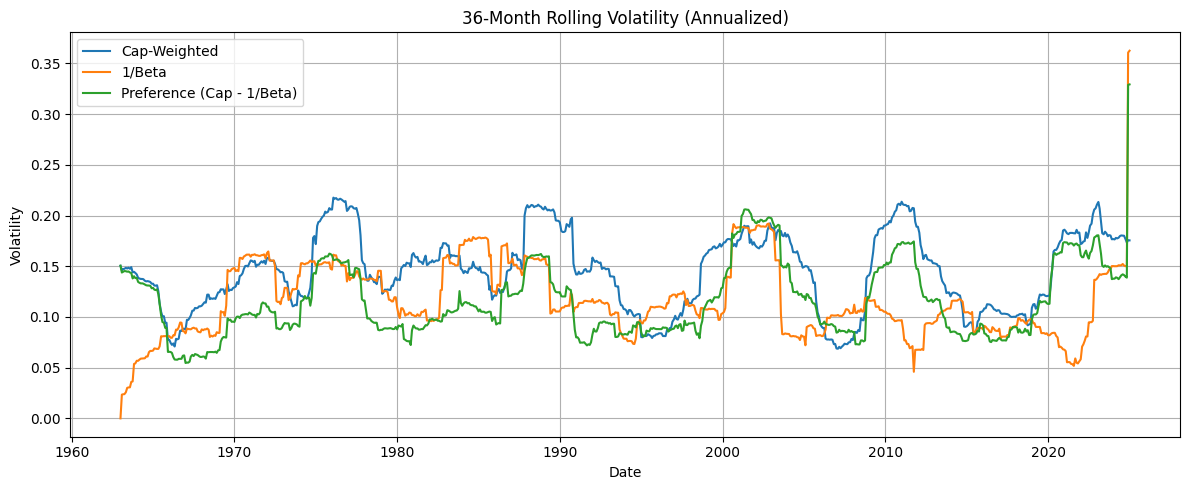

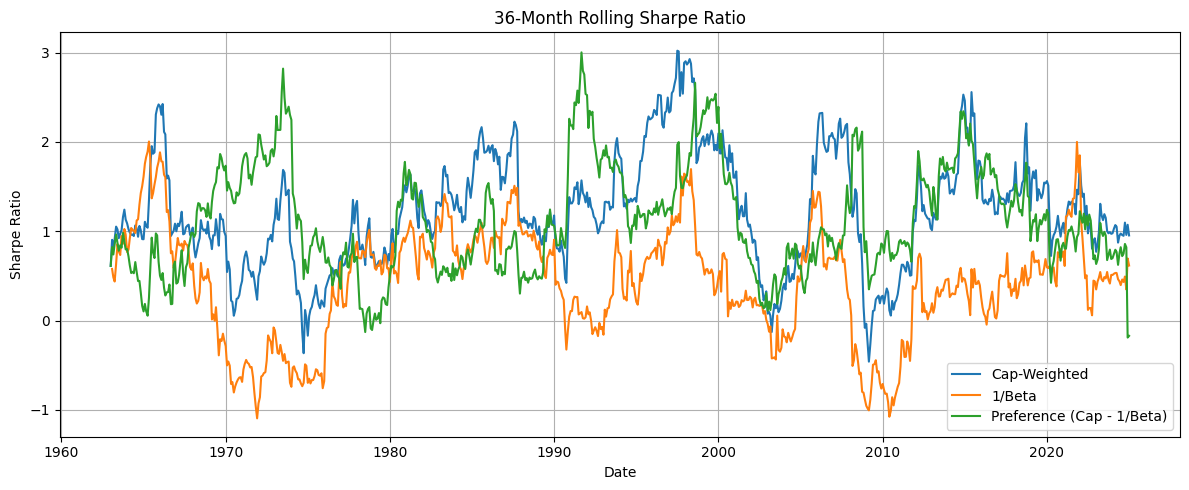

In [13]:
# === Cumulative Returns ===
plt.figure(figsize=(12, 5))
plt.plot(cumulative_returns)
plt.title("Cumulative Returns")
plt.ylabel("Log Return")
plt.xlabel("Date")
plt.legend(cumulative_returns.columns)
plt.grid(True)
plt.tight_layout()
plt.show()

# === Rolling Volatility ===
plt.figure(figsize=(12, 5))
plt.plot(rolling_vol)
plt.title(f"{window}-Month Rolling Volatility (Annualized)")
plt.ylabel("Volatility")
plt.xlabel("Date")
plt.legend(rolling_vol.columns)
plt.grid(True)
plt.tight_layout()
plt.show()

# === Rolling Sharpe Ratio ===
plt.figure(figsize=(12, 5))
plt.plot(rolling_sharpe)
plt.title(f"{window}-Month Rolling Sharpe Ratio")
plt.ylabel("Sharpe Ratio")
plt.xlabel("Date")
plt.legend(rolling_sharpe.columns)
plt.grid(True)
plt.tight_layout()
plt.show()


## EBC

In [14]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

def equal_abs_beta_contribution_weights(beta_row):
    #filter out nans and zero betas
    valid_betas = beta_row.dropna()
    valid_betas = valid_betas[valid_betas != 0]

    if valid_betas.empty:
        return pd.Series(dtype=float)

    betas = valid_betas.values
    n = len(betas)
    idx = valid_betas.index

    #objective function to minimize with target of 1/n
    def objective(w):
        contrib = w * betas
        return np.sum((contrib - 1/n)**2)

    #constraints: sum of weights = 1
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    ]

    #long only weights to mimic equal weight
    bounds = [(0, 1) for _ in range(n)]

    #start with inverted betas
    x0 = 1 / np.abs(betas)
    x0 = x0 / x0.sum()

    result = minimize(objective, x0, bounds=bounds, constraints=constraints)

    if not result.success:
        return pd.Series(dtype=float)

    weights = pd.Series(result.x, index=idx)

    full_weights = pd.Series(0.0, index=beta_row.index)
    full_weights.update(weights)

    return full_weights

In [15]:
rets

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1960-01-29,0.005155,-0.015000,-0.020785,0.0,-0.092262,0.000000,0.000000,0.0,-0.020833,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-02-29,0.046154,0.017767,0.009434,0.0,-0.021312,0.000000,0.000000,0.0,0.053192,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-03-31,-0.059553,-0.100249,-0.047170,0.0,0.038851,0.000000,0.000000,0.0,-0.005387,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-04-29,-0.081794,-0.056180,0.000000,0.0,-0.050407,0.000000,0.000000,0.0,0.010274,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-05-31,0.048851,-0.029762,-0.034654,0.0,0.029110,0.000000,0.000000,0.0,0.044068,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-30,0.000000,0.000000,0.000000,0.0,0.000000,0.013195,-0.001100,0.0,0.000000,-0.071535,...,0.0,0.013319,0.042292,-0.310823,0.321675,0.0,0.005460,0.0,0.122718,-0.077391
2024-09-30,0.000000,0.000000,0.000000,0.0,0.000000,0.206030,0.031548,0.0,0.000000,0.038948,...,0.0,0.062707,-0.016385,0.019284,0.010950,0.0,0.015013,0.0,-0.002580,0.221942
2024-10-31,0.000000,0.000000,0.000000,0.0,0.000000,-0.012676,-0.055659,0.0,0.000000,0.008538,...,0.0,-0.015826,0.025228,-0.046589,0.014313,0.0,0.041981,0.0,0.042466,-0.045025


In [17]:
from tqdm import tqdm
all_tickers = rets.columns
tqdm.pandas()

equal_abs_beta_weights = betas.progress_apply(
    lambda row: equal_abs_beta_contribution_weights(row).reindex(all_tickers, fill_value=0),
    axis=1
)

100%|██████████████████████████████████████████████████████████████████████████████| 780/780 [2:43:53<00:00, 12.61s/it]


In [18]:
# Compute EBC portfolio returns
ebc_return = (equal_abs_beta_weights * rets).sum(axis=1)
ebc_return.name = "EBC Portfolio"

# Preference: Cap-Weighted minus EBC
ret_pref_ebc = ret_cap - ebc_return
ret_pref_ebc.name = "Preference (Cap - EBC)"

# Add to returns_df
returns_df["EBC"] = ebc_return
returns_df["Preference (Cap - EBC)"] = ret_pref_ebc


In [19]:
returns_ebc = returns_df[["Cap-Weighted", "EBC", "Preference (Cap - EBC)"]]

In [20]:
rolling_vol = returns_ebc.rolling(window).std() * np.sqrt(12)
rolling_sharpe = returns_ebc.rolling(window).mean() / returns_ebc.rolling(window).std() * np.sqrt(12)
cumulative_returns = np.log1p(returns_ebc).cumsum()


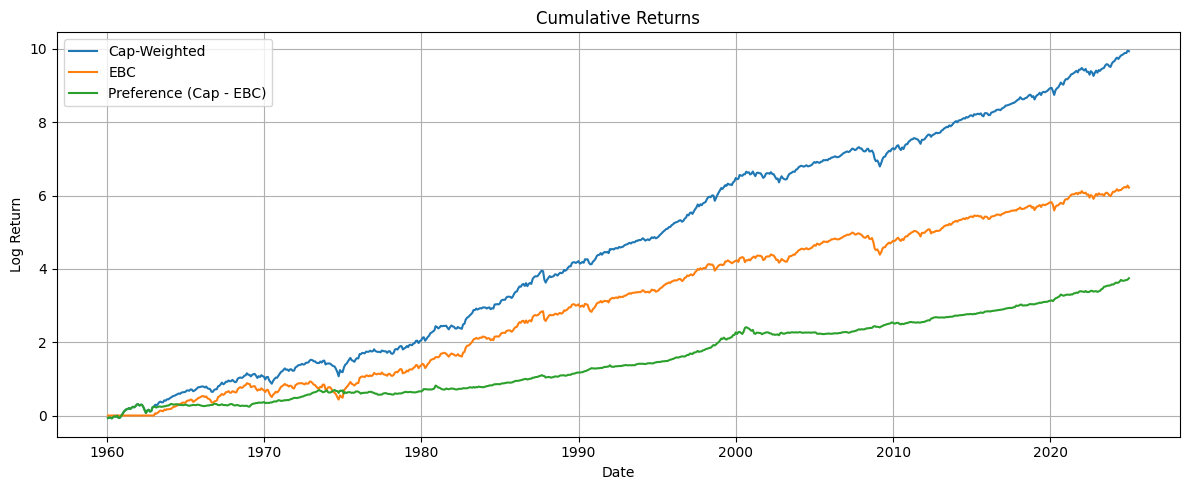

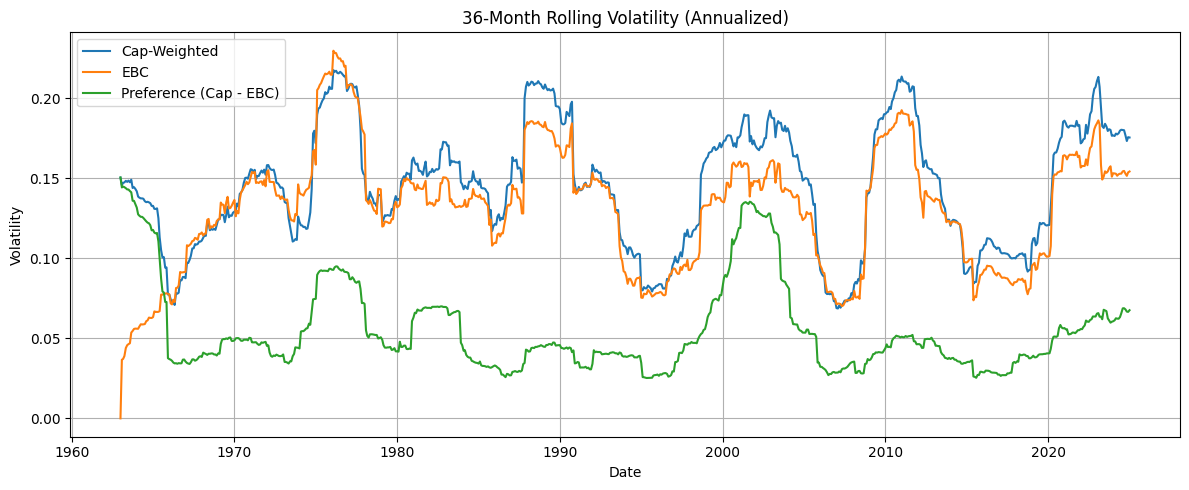

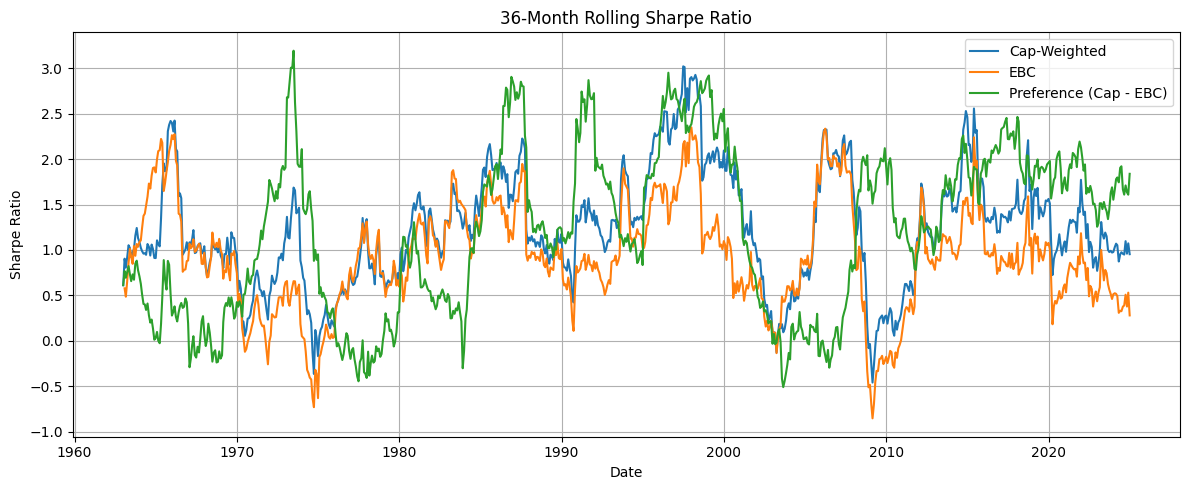

In [21]:

# === Cumulative Returns ===
plt.figure(figsize=(12, 5))
plt.plot(cumulative_returns)
plt.title("Cumulative Returns")
plt.ylabel("Log Return")
plt.xlabel("Date")
plt.legend(cumulative_returns.columns)
plt.grid(True)
plt.tight_layout()
plt.show()

# === Rolling Volatility ===
plt.figure(figsize=(12, 5))
plt.plot(rolling_vol)
plt.title(f"{window}-Month Rolling Volatility (Annualized)")
plt.ylabel("Volatility")
plt.xlabel("Date")
plt.legend(rolling_vol.columns)
plt.grid(True)
plt.tight_layout()
plt.show()

# === Rolling Sharpe Ratio ===
plt.figure(figsize=(12, 5))
plt.plot(rolling_sharpe)
plt.title(f"{window}-Month Rolling Sharpe Ratio")
plt.ylabel("Sharpe Ratio")
plt.xlabel("Date")
plt.legend(rolling_sharpe.columns)
plt.grid(True)
plt.tight_layout()
plt.show()


# PCA

In [22]:
pca_input = returns_df[[
    "Preference Portfolio (CW-EW)",
    "Preference (Cap - 1/Beta)",
    "Preference (Cap - EBC)"
]].dropna()

In [23]:
from sklearn.preprocessing import StandardScaler

scaled = StandardScaler().fit_transform(pca_input)


In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
components = pca.fit_transform(scaled)

explained_var = pca.explained_variance_ratio_
loadings = pd.DataFrame(pca.components_, columns=pca_input.columns)


In [25]:
pd.Series(explained_var, index=[f"PC{i+1}" for i in range(len(explained_var))])


PC1    0.604111
PC2    0.314082
PC3    0.081807
dtype: float64

In [26]:
loadings = pd.DataFrame(pca.components_, columns=pca_input.columns, index=[f"PC{i+1}" for i in range(3)])
loadings


,Preference Portfolio (CW-EW),Preference (Cap - 1/Beta),Preference (Cap - EBC)
PC1,0.507263,0.510993,0.693953
PC2,0.710120,-0.704080,-0.000630
PC3,-0.488276,-0.493110,0.720020


<Axes: title={'center': 'Principal Components Time Series'}, xlabel='date'>

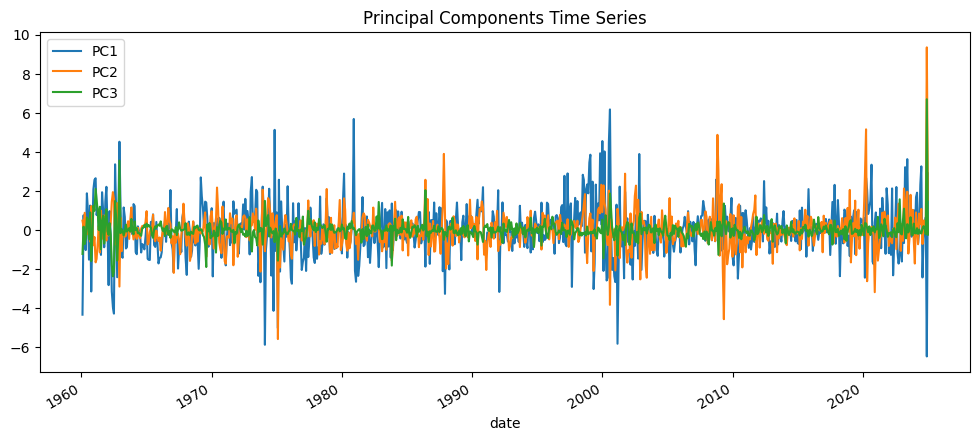

In [27]:
pc_scores = pd.DataFrame(components, index=pca_input.index, columns=[f"PC{i+1}" for i in range(3)])
pc_scores.plot(title="Principal Components Time Series", figsize=(12, 5))


## Asset Pricing

In [28]:
import statsmodels.api as sm

def capm_regression(returns_df, portfolio_col, market_col="Cap-Weighted"):
    y = returns_df[portfolio_col]
    x = returns_df[market_col]
    x = sm.add_constant(x)

    model = sm.OLS(y, x).fit()

    alpha = model.params["const"]
    beta = model.params[market_col]
    alpha_tstat = model.tvalues["const"]
    r_squared = model.rsquared

    alpha_se = model.bse["const"]
    beta_se = model.bse[market_col]
    alpha_pval = model.pvalues["const"]
    beta_pval = model.pvalues[market_col]

    tracking_error = model.resid.std()
    info_ratio = alpha / tracking_error if tracking_error != 0 else float('nan')

    return {
        "alpha": alpha,
        "beta": beta,
        "alpha_tstat": alpha_tstat,
        "r_squared": r_squared,
        "alpha_se": alpha_se,
        "beta_se": beta_se,
        "alpha_pval": alpha_pval,
        "beta_pval": beta_pval,
        "tracking_error": tracking_error,
        "info_ratio": info_ratio,
        "model": model
    }


In [29]:
def print_capm_results(name, results):
    print(f"{name}:")
    print(f"  Alpha             : {results['alpha']*100:.5f}%")
    print(f"  Alpha t-stat      : {results['alpha_tstat']:.2f}")
    print(f"  Alpha SE          : {results['alpha_se']:.5f}")
    print(f"  Alpha p-value     : {results['alpha_pval']:.4f}")
    print(f"  Beta              : {results['beta']:.3f}")
    print(f"  Beta SE           : {results['beta_se']:.5f}")
    print(f"  Beta p-value      : {results['beta_pval']:.4f}")
    print(f"  R²                : {results['r_squared']:.3f}")
    print(f"  Tracking Error    : {results['tracking_error']:.4f}")
    print(f"  Information Ratio : {results['info_ratio']:.3f}")
    print()


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_capm_scatter(returns_df, portfolio_col, market_col="Cap-Weighted"):
    x = returns_df[market_col]
    y = returns_df[portfolio_col]
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(7, 5))
    sns.regplot(x=x, y=y, line_kws={"color": "red"}, scatter_kws={"alpha": 0.4})
    plt.xlabel("Market Return (Cap-Weighted)")
    plt.ylabel(f"{portfolio_col} Return")
    plt.title(f"CAPM Scatter: {portfolio_col} vs Market")
    plt.axhline(0, color="black", linewidth=0.5)
    plt.axvline(0, color="black", linewidth=0.5)
    plt.tight_layout()
    plt.show()


In [31]:
def plot_residuals(model, title):
    residuals = model.resid
    plt.figure(figsize=(7, 4))
    plt.plot(residuals, label="Residuals")
    plt.axhline(0, color="red", linestyle="--")
    plt.title(f"Residuals Over Time: {title}")
    plt.ylabel("Residual")
    plt.xlabel("Time")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [32]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_rolling_beta(returns_df, portfolio_col, market_col="Cap-Weighted", window=36):
    subset = returns_df[[portfolio_col, market_col]].dropna().copy()

    betas = []
    dates = []

    for i in range(window, len(subset) + 1):
        window_df = subset.iloc[i - window : i]
        portfolio = window_df[portfolio_col]
        market = window_df[market_col]
        beta = portfolio.cov(market) / market.var()
        betas.append(beta)
        dates.append(window_df.index[-1])

    rolling_beta = pd.Series(betas, index=dates)

    plt.figure(figsize=(10, 4))
    plt.plot(rolling_beta.index, rolling_beta.values, label=f"Rolling Beta: {portfolio_col}")
    plt.axhline(0, color="black", linestyle="--", linewidth=0.7)
    plt.title(f"{portfolio_col} Rolling Beta (window = {window} months)")
    plt.xlabel("Date")
    plt.ylabel("Beta")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [33]:
results_cw_ew = capm_regression(returns_df, "Preference Portfolio (CW-EW)")
results_ebc = capm_regression(returns_df, "EBC")

print_capm_results("CW–EW:", results_cw_ew)
print_capm_results("EBC:  ", results_ebc)


CW–EW::
  Alpha             : 0.40625%
  Alpha t-stat      : 6.66
  Alpha SE          : 0.00061
  Alpha p-value     : 0.0000
  Beta              : -0.086
  Beta SE           : 0.01354
  Beta p-value      : 0.0000
  R²                : 0.049
  Tracking Error    : 0.0162
  Information Ratio : 0.250

EBC:  :
  Alpha             : -0.24180%
  Alpha t-stat      : -3.83
  Alpha SE          : 0.00063
  Alpha p-value     : 0.0001
  Beta              : 0.813
  Beta SE           : 0.01400
  Beta p-value      : 0.0000
  R²                : 0.813
  Tracking Error    : 0.0168
  Information Ratio : -0.144



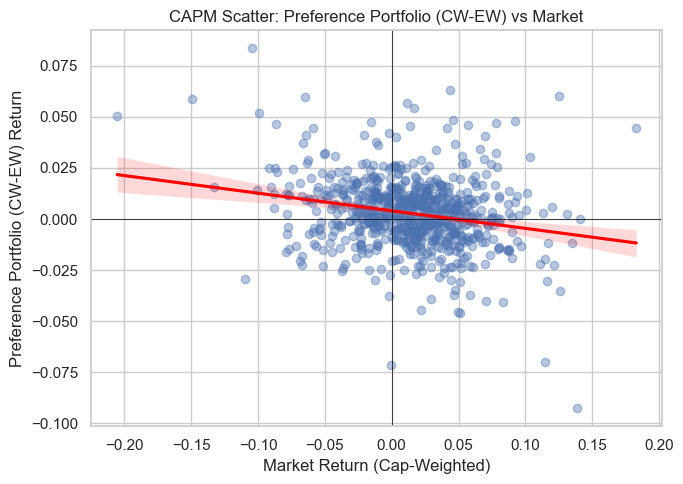

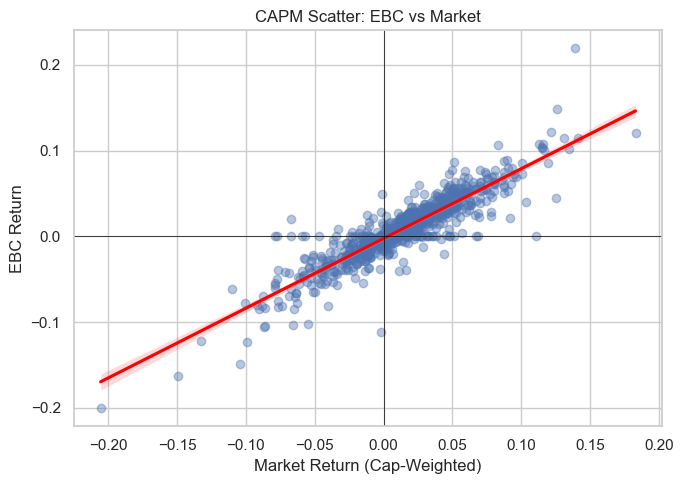

In [34]:
plot_capm_scatter(returns_df, "Preference Portfolio (CW-EW)")
plot_capm_scatter(returns_df, "EBC")


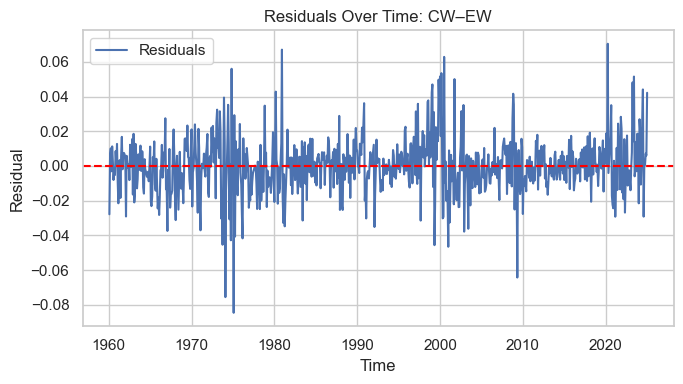

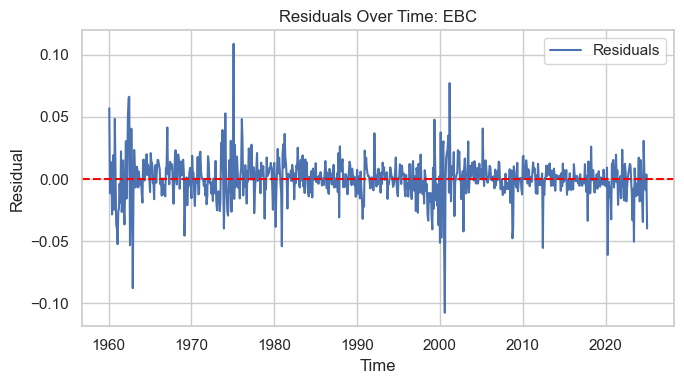

In [35]:
plot_residuals(results_cw_ew["model"], "CW–EW")
plot_residuals(results_ebc["model"], "EBC")


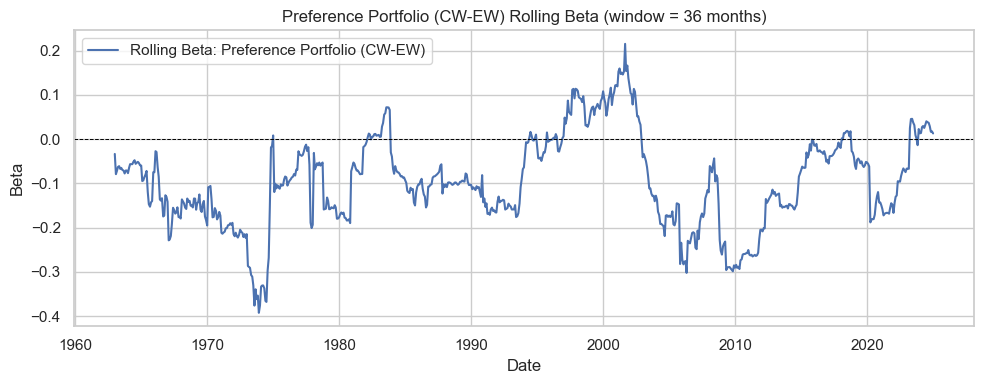

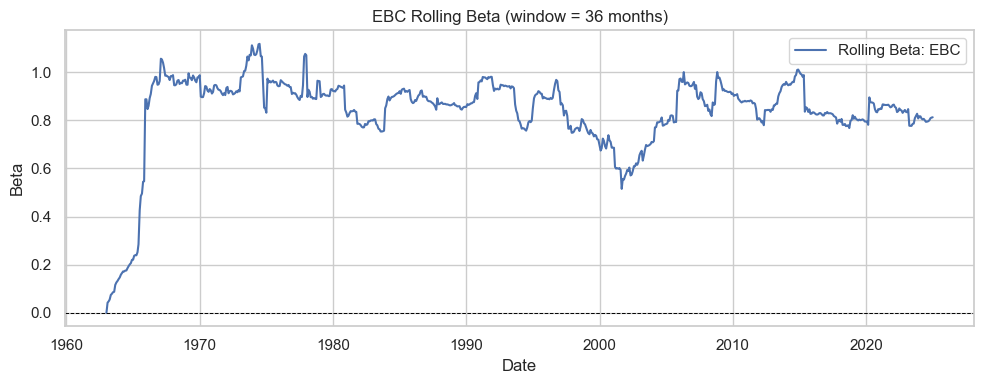

In [36]:
plot_rolling_beta(returns_df, "Preference Portfolio (CW-EW)")
plot_rolling_beta(returns_df, "EBC")


In [37]:
returns_df

,Cap-Weighted,Equal-Weighted,Preference Portfolio (CW-EW),1/Beta,Preference (Cap - 1/Beta),EBC,Preference (Cap - EBC)
date,,,,,,,
1960-01-29,-0.067093,-0.049087,-0.018005,0.000000,-0.067093,0.000000,-0.067093
1960-02-29,0.017111,0.007490,0.009621,0.000000,0.017111,0.000000,0.017111
1960-03-31,-0.010623,-0.025784,0.015161,0.000000,-0.010623,0.000000,-0.010623
1960-04-29,-0.013724,-0.015902,0.002178,0.000000,-0.013724,0.000000,-0.013724
1960-05-31,0.037913,0.025842,0.012071,0.000000,0.037913,0.000000,0.037913
...,...,...,...,...,...,...,...
2024-08-30,0.028116,0.024943,0.003173,0.045284,-0.017168,0.026317,0.001798
2024-09-30,0.025856,0.023297,0.002560,0.009644,0.016212,0.016862,0.008994
2024-10-31,-0.004786,-0.016410,0.011624,-0.028102,0.023316,-0.015225,0.010439


# Weight optimizaiton(inv beta)

In [39]:
ann_factor = 12  # 日频改为 252
inv_beta_score = 1 / betas.abs()
stock_vol = rets.rolling(window).std() * np.sqrt(ann_factor)   # 个股年化波动

In [40]:
def invbeta_optimized_weights(scores_row, vol_row, wmax=0.02, eps=1e-6):
    ok = scores_row.notna() & vol_row.notna() & vol_row.gt(0)
    if not ok.any():
        return pd.Series(0.0, index=scores_row.index)

    s = scores_row.where(ok)
    v = vol_row.where(ok)

    # 去极值 + 标准化
    s = s.clip(lower=s.quantile(0.02), upper=s.quantile(0.98))
    s = (s - s.mean()) / (s.std(ddof=0) + eps)

    raw = (s / (v + eps)).fillna(0.0)

    long  = raw.clip(lower=0)
    short = (-raw.clip(upper=0))

    if long.sum() == 0 and short.sum() == 0:
        return pd.Series(0.0, index=scores_row.index)

    long  = 0.5 * long  / (long.sum()  + eps)
    short = 0.5 * short / (short.sum() + eps)
    w = long - short

    # 单名上限 + 重新归一化
    w = w.clip(-wmax, wmax)
    pos = w.clip(lower=0); neg = (-w.clip(upper=0))
    if pos.sum() > 0: pos = 0.5 * pos / pos.sum()
    if neg.sum() > 0: neg = 0.5 * neg / neg.sum()
    w = pos - neg
    return w.reindex(scores_row.index).fillna(0.0)


# Method 1

In [55]:
w_all = pd.DataFrame(index=inv_beta_score.index, columns=inv_beta_score.columns, dtype=float)
for dt in inv_beta_score.index:
    w_all.loc[dt] = invbeta_optimized_weights(inv_beta_score.loc[dt], stock_vol.loc[dt])

w_all = w_all.shift(1)
ret_invbeta_opt_all = (rets * w_all).sum(axis=1).rename("InvBeta All")
pref_invbeta_opt_all = (ret_cap - ret_invbeta_opt_all).rename("Preference (Cap - InvBeta All)")


C:\Users\Username\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\Username\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\Username\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\Username\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\Username\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 

## Method 2

In [56]:
def topbottom_mask(scores_row, q=0.2):
    s = scores_row.dropna()
    k = int(len(s) * q)
    if k == 0: 
        return pd.Series(False, index=scores_row.index)
    keep = s.nlargest(k).index.union(s.nsmallest(k).index)
    return scores_row.index.isin(keep)

w_tb = pd.DataFrame(index=inv_beta_score.index, columns=inv_beta_score.columns, dtype=float)
for dt in inv_beta_score.index:
    mask = topbottom_mask(inv_beta_score.loc[dt], q=0.2)
    scores = inv_beta_score.loc[dt].where(mask)
    vols   = stock_vol.loc[dt].where(mask)
    w_tb.loc[dt] = invbeta_optimized_weights(scores, vols)

w_tb = w_tb.shift(1)
ret_invbeta_opt_tb = (rets * w_tb).sum(axis=1).rename("InvBeta TopBottom")
pref_invbeta_opt_tb = (ret_cap - ret_invbeta_opt_tb).rename("Preference (Cap - InvBeta TB)")


In [57]:
returns_df["InvBeta All"] = ret_invbeta_opt_all
returns_df["InvBeta TopBottom"] = ret_invbeta_opt_tb
returns_df["Preference (Cap - InvBeta All)"] = pref_invbeta_opt_all
returns_df["Preference (Cap - InvBeta TB)"]  = pref_invbeta_opt_tb

compare_cols = [
    "Cap-Weighted",
    "InvBeta All", "Preference (Cap - InvBeta All)",
    "InvBeta TopBottom", "Preference (Cap - InvBeta TB)"
]
returns_cmp = returns_df[compare_cols]

rolling_vol_cmp    = returns_cmp.rolling(window).std() * np.sqrt(ann_factor)
rolling_sharpe_cmp = returns_cmp.rolling(window).mean() / returns_cmp.rolling(window).std() * np.sqrt(ann_factor)
cumlog_cmp         = np.log1p(returns_cmp).cumsum()


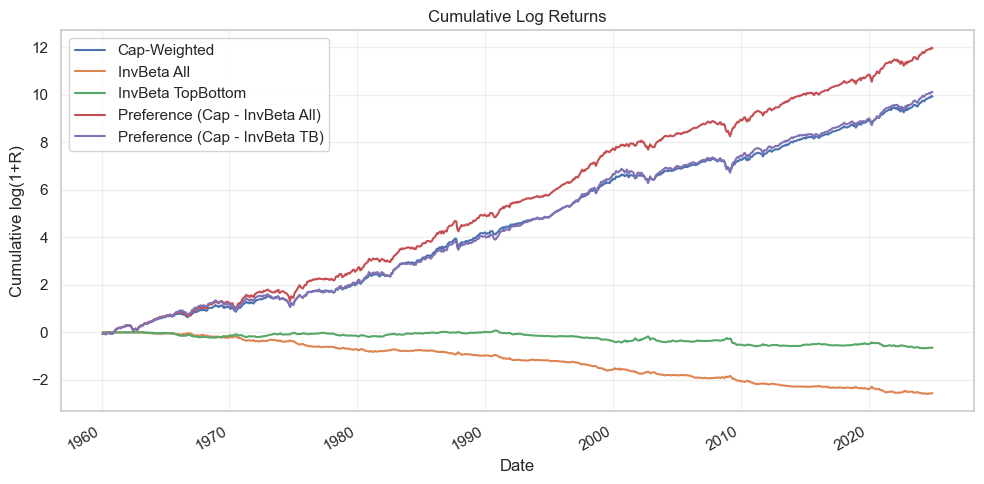

In [58]:

plot_cols = [
    "Cap-Weighted",
    "InvBeta All",
    "InvBeta TopBottom",
    "Preference (Cap - InvBeta All)",
    "Preference (Cap - InvBeta TB)"
]
cols = [c for c in plot_cols if c in returns_df.columns]
cumlog = np.log1p(returns_df[cols]).cumsum()

plt.figure(figsize=(10, 5))
cumlog.plot(ax=plt.gca(), linewidth=1.5)
plt.title("Cumulative Log Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative log(1+R)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


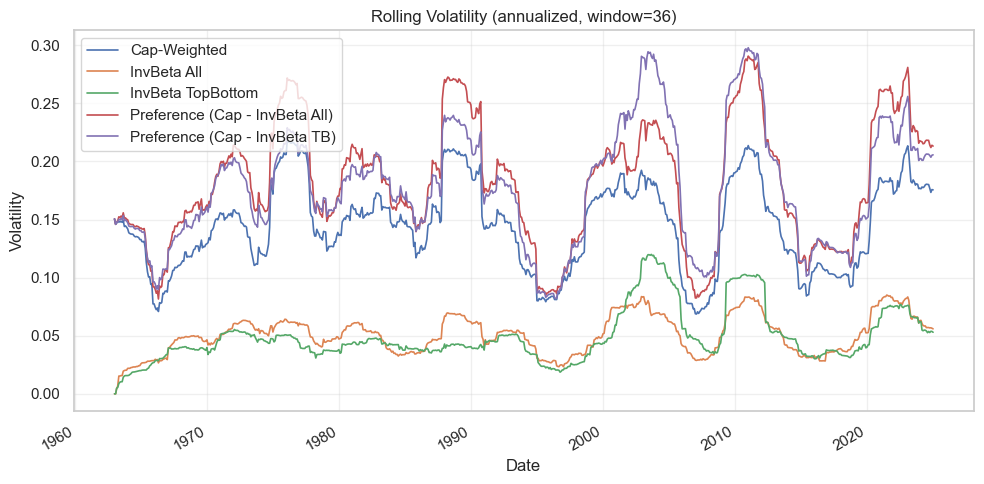

In [59]:
rolling_vol = returns_df[cols].rolling(window).std() * np.sqrt(ann_factor)

plt.figure(figsize=(10, 5))
rolling_vol.plot(ax=plt.gca(), linewidth=1.2)
plt.title(f"Rolling Volatility (annualized, window={window})")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

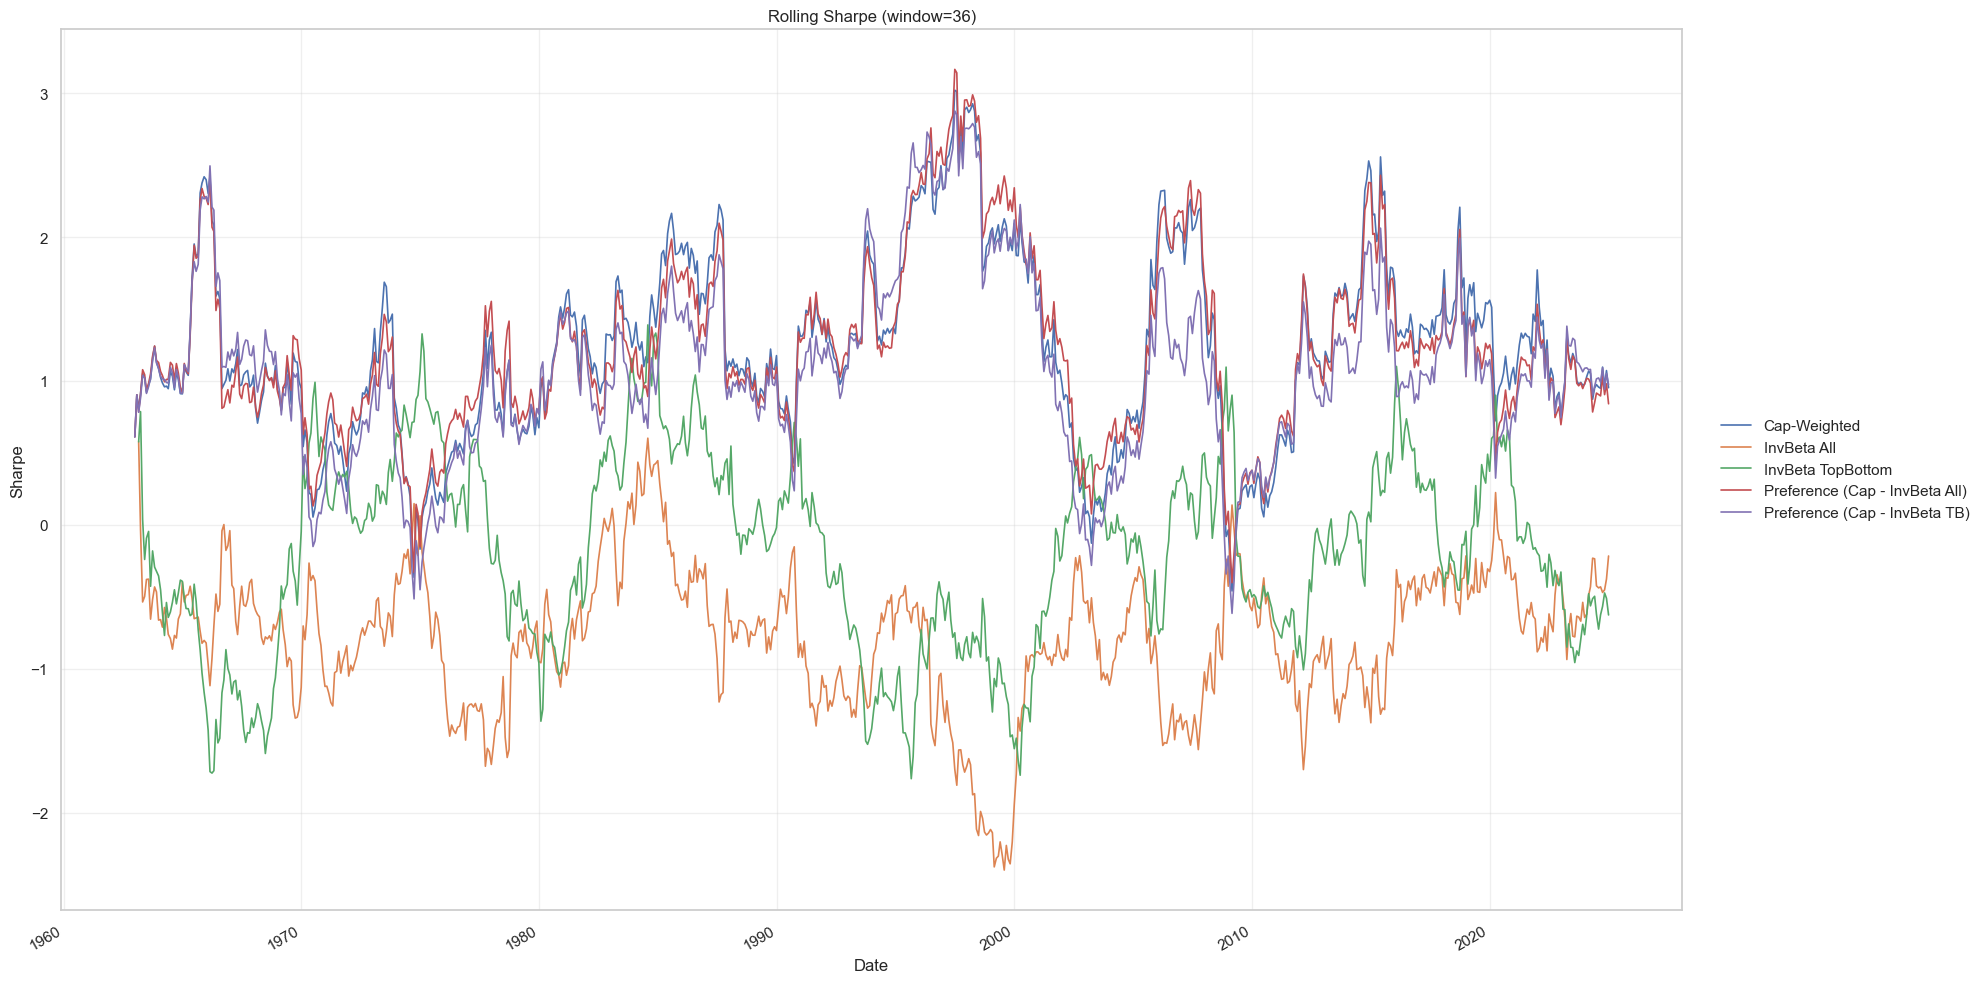

In [67]:
roll_mean = returns_df[cols].rolling(window).mean()
roll_std  = returns_df[cols].rolling(window).std()
rolling_sharpe = roll_mean / roll_std * np.sqrt(ann_factor)

fig, ax = plt.subplots(figsize=(20, 10))
rolling_sharpe.plot(ax=ax, linewidth=1.2)

ax.set_title(f"Rolling Sharpe (window={window})")
ax.set_xlabel("Date")
ax.set_ylabel("Sharpe")
ax.grid(True, alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0., frameon=False)
fig.tight_layout()
plt.show()

fig.savefig('Inv_Beta_rolling_sharpe.png', dpi=300, bbox_inches='tight', facecolor='white')

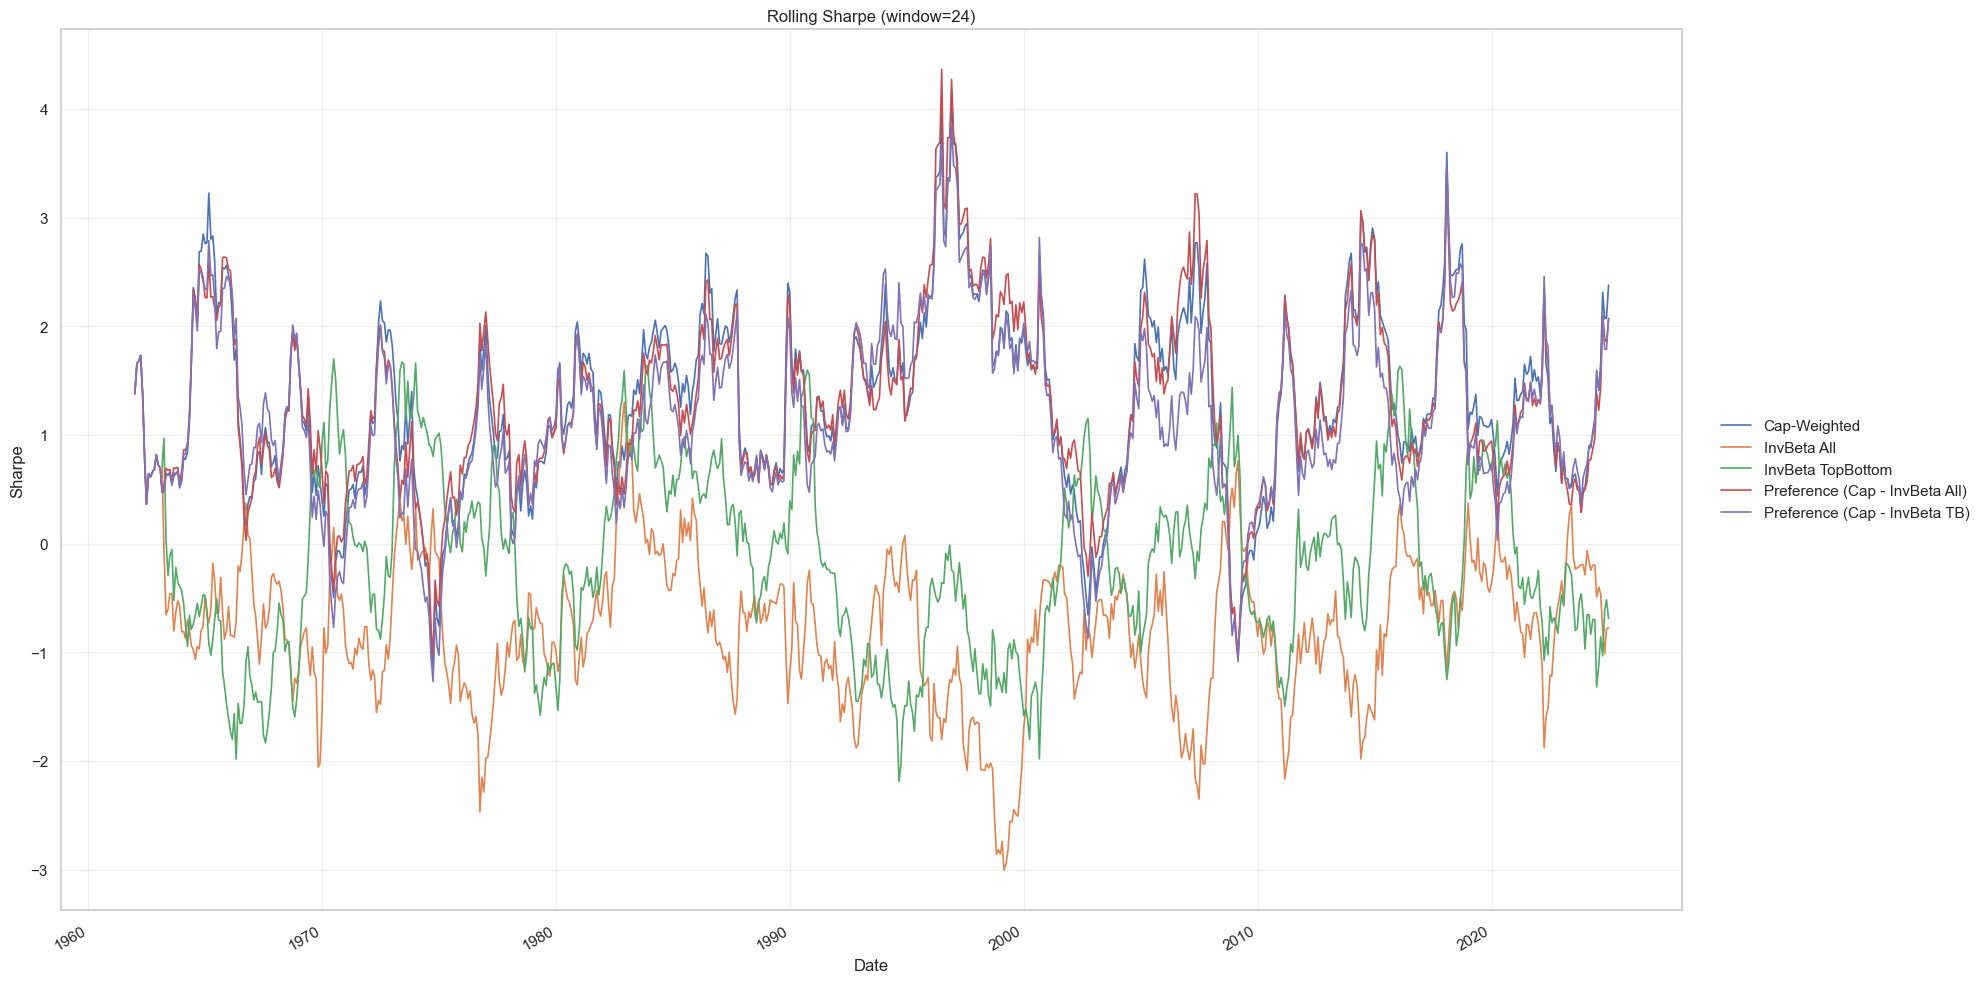

In [68]:
window=24
roll_mean = returns_df[cols].rolling(window).mean()
roll_std  = returns_df[cols].rolling(window).std()
rolling_sharpe = roll_mean / roll_std * np.sqrt(ann_factor)

fig, ax = plt.subplots(figsize=(20, 10))
rolling_sharpe.plot(ax=ax, linewidth=1.2)

ax.set_title(f"Rolling Sharpe (window={window})")
ax.set_xlabel("Date")
ax.set_ylabel("Sharpe")
ax.grid(True, alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0., frameon=False)
fig.tight_layout()
plt.show()

fig.savefig('Inv_Beta_rolling_sharpe24.png', dpi=300, bbox_inches='tight', facecolor='white')

In [69]:
def ann_mean(x, af):  
    return x.mean() * af

summary = pd.DataFrame({
    "Ann.Return": returns_df[cols].apply(ann_mean, af=ann_factor, axis=0),
    "Ann.Vol":    returns_df[cols].std() * np.sqrt(ann_factor),
}, index=cols)
summary["Sharpe"] = summary["Ann.Return"] / summary["Ann.Vol"]
summary.round(3)


,Ann.Return,Ann.Vol,Sharpe
Cap-Weighted,0.165,0.149,1.108
InvBeta All,-0.038,0.052,-0.724
InvBeta TopBottom,-0.008,0.053,-0.160
Preference (Cap - InvBeta All),0.203,0.187,1.086
Preference (Cap - InvBeta TB),0.173,0.183,0.945


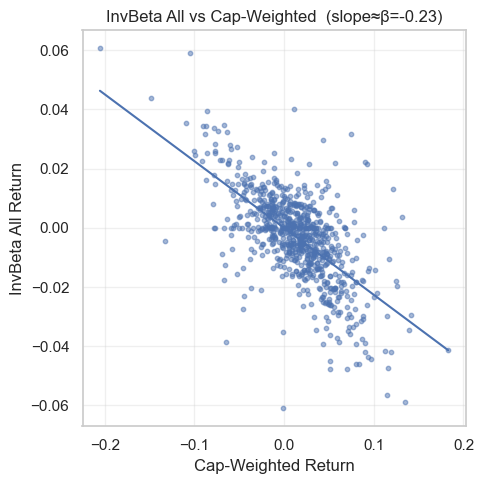

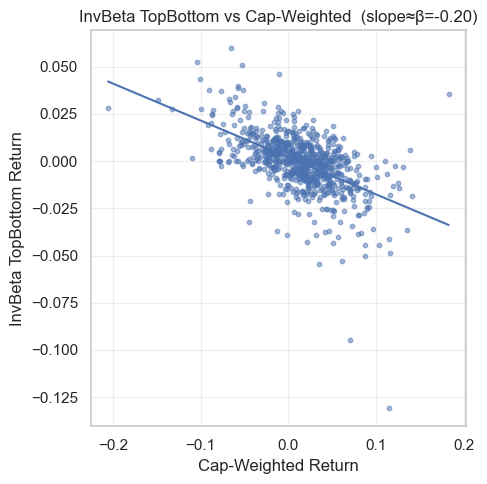

In [72]:
if "Cap-Weighted" in returns_df.columns:
    base = returns_df["Cap-Weighted"].dropna()
    target_cols = [c for c in ["InvBeta All", "InvBeta TopBottom"] if c in returns_df.columns]
    for c in target_cols:
        s = returns_df[c].reindex(base.index).dropna()
        xy = pd.concat([base, s], axis=1).dropna()
        if len(xy) == 0:
            continue

        plt.figure(figsize=(5,5))
        plt.scatter(xy.iloc[:,0], xy.iloc[:,1], s=10, alpha=0.5)
        
        coef = np.polyfit(xy.iloc[:,0], xy.iloc[:,1], 1)
        xline = np.linspace(xy.iloc[:,0].min(), xy.iloc[:,0].max(), 100)
        yline = coef[0]*xline + coef[1]
        plt.plot(xline, yline)  
        plt.title(f"{c} vs Cap-Weighted  (slope≈β={coef[0]:.2f})")
        plt.xlabel("Cap-Weighted Return")
        plt.ylabel(f"{c} Return")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [73]:
def capm_regression_simple(df, port_col, mkt_col="Cap-Weighted"):
    y = df[port_col].dropna()
    x = df[mkt_col].reindex(y.index).dropna()
    y = y.reindex(x.index)
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    out = {
        "alpha": model.params.get("const", np.nan),
        "beta":  model.params.get(mkt_col, np.nan),
        "alpha_t": model.tvalues.get("const", np.nan),
        "alpha_p": model.pvalues.get("const", np.nan),
        "R2": model.rsquared,
    }
    return out

capm_rows = []
for col in returns_cmp.columns:
    if col == "Cap-Weighted": continue
    capm_rows.append(pd.Series(capm_regression_simple(returns_cmp, col), name=col))
capm_table = pd.DataFrame(capm_rows)
display(capm_table)


,alpha,beta,alpha_t,alpha_p,R2
InvBeta All,-0.000062,-0.225729,-0.141220,0.887733,0.410560
Preference (Cap - InvBeta All),0.000062,1.225729,0.141220,0.887733,0.953570
InvBeta TopBottom,0.001976,-0.195434,4.094235,0.000047,0.299707
Preference (Cap - InvBeta TB),-0.001976,1.195434,-4.094235,0.000047,0.941221


In [74]:
corr_mat = returns_cmp.corr()
display(corr_mat.round(2))

,Cap-Weighted,InvBeta All,Preference (Cap - InvBeta All),InvBeta TopBottom,Preference (Cap - InvBeta TB)
Cap-Weighted,1.00,-0.64,0.98,-0.55,0.97
InvBeta All,-0.64,1.00,-0.79,0.54,-0.68
Preference (Cap - InvBeta All),0.98,-0.79,1.00,-0.59,0.96
InvBeta TopBottom,-0.55,0.54,-0.59,1.00,-0.73
Preference (Cap - InvBeta TB),0.97,-0.68,0.96,-0.73,1.00


In [75]:
ff5 = pd.read_csv(r"C:\Users\Username\OneDrive\Desktop\Invesco_project\F-F_Research_Data_5_Factors_2x3.csv", skiprows =3, nrows =742)
ff5.rename(columns={"Unnamed: 0": "Date"}, inplace=True)
ff5["Date"] = pd.to_datetime(ff5["Date"], format="%Y%m")
ff5.set_index("Date", inplace=True)
ff5 = ff5.astype(float) / 100

ffm = pd.read_csv(r"C:\Users\Username\OneDrive\Desktop\Invesco_project\F-F_Momentum_Factor.csv",skiprows= 13, nrows = 1180)
ffm.rename(columns={"Unnamed: 0": "Date"}, inplace=True)
ffm["Date"] = pd.to_datetime(ffm["Date"], format="%Y%m")
ffm.set_index("Date", inplace=True)
ffm = ffm.astype(float) / 100

ff = ff5.join(ffm, how="inner")
ff

,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom
Date,,,,,,,
1963-07-01,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027,0.0101
1963-08-01,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025,0.0100
1963-09-01,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027,0.0012
1963-10-01,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029,0.0313
1963-11-01,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027,-0.0078
...,...,...,...,...,...,...,...
2024-12-01,-0.0315,-0.0384,-0.0300,0.0191,-0.0121,0.0037,-0.0030
2025-01-01,0.0280,-0.0122,0.0162,-0.0233,-0.0324,0.0037,0.0095
2025-02-01,-0.0243,-0.0493,0.0491,0.0109,0.0306,0.0033,-0.0082


In [77]:
returns_df = returns_df.copy()
returns_df.index = returns_df.index.to_period('M').to_timestamp('M')  

ffm = ff.copy()
ffm.index = ffm.index.to_period('M').to_timestamp('M')               


common_idx = returns_df.index.intersection(ffm.index)
ret = returns_df.loc[common_idx]
ffm = ffm.loc[common_idx]
print(ret.shape, ffm.shape)

(738, 15) (738, 7)


In [78]:
excess = ret.sub(ffm['RF'], axis=0)   # R_p - RF
excess.head()

,Cap-Weighted,Equal-Weighted,Preference Portfolio (CW-EW),1/Beta,Preference (Cap - 1/Beta),EBC,Preference (Cap - EBC),InvBeta Opt (All),InvBeta Opt (TopBottom),Preference (Cap - InvBeta Opt All),Preference (Cap - InvBeta Opt TB),InvBeta All,InvBeta TopBottom,Preference (Cap - InvBeta All),Preference (Cap - InvBeta TB)
1963-07-31,-0.003284,-0.014061,0.008077,-0.006173,0.000189,-0.012273,0.006289,-0.002598,-0.001235,-0.003385,-0.004749,-0.002598,-0.001235,-0.003385,-0.004749
1963-08-31,0.052482,0.055487,-0.005505,0.031996,0.017987,0.045820,0.004163,-0.023079,-0.019262,0.073061,0.069244,-0.023079,-0.019262,0.073061,0.069244
1963-09-30,-0.011536,-0.022218,0.007982,-0.010638,-0.003598,-0.016935,0.002699,0.004447,0.007122,-0.018683,-0.021358,0.004447,0.007122,-0.018683,-0.021358
1963-10-31,0.035815,0.023347,0.009568,0.068115,-0.035200,0.022318,0.010597,0.001958,-0.008344,0.030957,0.041259,0.001958,-0.008344,0.030957,0.041259
1963-11-30,-0.005499,-0.006967,-0.001232,-0.011441,0.003242,-0.007168,-0.001031,-0.004841,-0.004082,-0.003358,-0.004117,-0.004841,-0.004082,-0.003358,-0.004117


In [90]:
excess.columns

Index(['Cap-Weighted', 'Equal-Weighted', 'Preference Portfolio (CW-EW)',
       '1/Beta', 'Preference (Cap - 1/Beta)', 'EBC', 'Preference (Cap - EBC)',
       'InvBeta Opt (All)', 'InvBeta Opt (TopBottom)',
       'Preference (Cap - InvBeta Opt All)',
       'Preference (Cap - InvBeta Opt TB)', 'InvBeta All', 'InvBeta TopBottom',
       'Preference (Cap - InvBeta All)', 'Preference (Cap - InvBeta TB)'],
      dtype='object')

In [91]:
excess.drop(['InvBeta Opt (All)', 'InvBeta Opt (TopBottom)',
       'Preference (Cap - InvBeta Opt All)',
       'Preference (Cap - InvBeta Opt TB)'], axis=1, inplace=True)

excess.head(3)

,Cap-Weighted,Equal-Weighted,Preference Portfolio (CW-EW),1/Beta,Preference (Cap - 1/Beta),EBC,Preference (Cap - EBC),InvBeta All,InvBeta TopBottom,Preference (Cap - InvBeta All),Preference (Cap - InvBeta TB)
1963-07-31,-0.003284,-0.014061,0.008077,-0.006173,0.000189,-0.012273,0.006289,-0.002598,-0.001235,-0.003385,-0.004749
1963-08-31,0.052482,0.055487,-0.005505,0.031996,0.017987,0.045820,0.004163,-0.023079,-0.019262,0.073061,0.069244
1963-09-30,-0.011536,-0.022218,0.007982,-0.010638,-0.003598,-0.016935,0.002699,0.004447,0.007122,-0.018683,-0.021358


In [92]:
def nw_t(res, lags=6):
    cov = sm.stats.sandwich_covariance.cov_hac(res, nlags=lags)
    se = np.sqrt(np.diag(cov))
    return pd.Series(res.params.values / se, index=res.params.index)

def run_ff5m(y, Xf, nw_lags=6):
    X = Xf[['Mkt-RF','SMB','HML','RMW','CMA','Mom']]
    X = sm.add_constant(X)
    m = sm.OLS(y, X, missing='drop').fit()
    t = nw_t(m, lags=nw_lags)
    alpha_ann = m.params['const'] * 12
    return {
        'alpha_ann_%': alpha_ann * 100,
        't_alpha(NW)': t['const'],
        'beta_MKT': m.params['Mkt-RF'],
        'beta_SMB': m.params['SMB'],
        'beta_HML': m.params['HML'],
        'beta_RMW': m.params['RMW'],
        'beta_CMA': m.params['CMA'],
        'beta_Mom': m.params['Mom'],
        'R2': m.rsquared,
        'Obs': int(m.nobs),
    }

rows = []
for col in excess.columns:
    rows.append({'Strategy': col, **run_ff5m(excess[col], ffm)})
summary = pd.DataFrame(rows).set_index('Strategy').sort_values('alpha_ann_%', ascending=False)
summary.round(3)

,alpha_ann_%,t_alpha(NW),beta_MKT,beta_SMB,beta_HML,beta_RMW,beta_CMA,beta_Mom,R2,Obs
Strategy,,,,,,,,,,
Preference (Cap - InvBeta All),7.444,10.828,1.231,-0.123,0.082,0.177,0.130,-0.098,0.953,738
Preference (Cap - InvBeta TB),6.282,7.912,1.146,-0.036,0.054,-0.053,-0.020,-0.125,0.950,738
Cap-Weighted,5.495,14.868,0.993,-0.149,0.002,0.064,0.058,-0.018,0.989,738
Preference (Cap - 1/Beta),5.135,3.457,0.456,-0.284,-0.003,-0.050,-0.030,-0.055,0.275,738
Preference (Cap - EBC),1.855,2.748,0.144,-0.279,-0.114,-0.107,-0.105,0.050,0.455,738
Preference Portfolio (CW-EW),0.738,1.155,-0.072,-0.325,-0.166,-0.101,-0.079,0.110,0.623,738
Equal-Weighted,0.387,0.828,1.069,0.179,0.160,0.170,0.142,-0.132,0.964,738
EBC,-0.731,-1.492,0.852,0.133,0.107,0.176,0.169,-0.072,0.916,738
1/Beta,-4.011,-2.764,0.540,0.138,-0.004,0.119,0.094,0.033,0.350,738


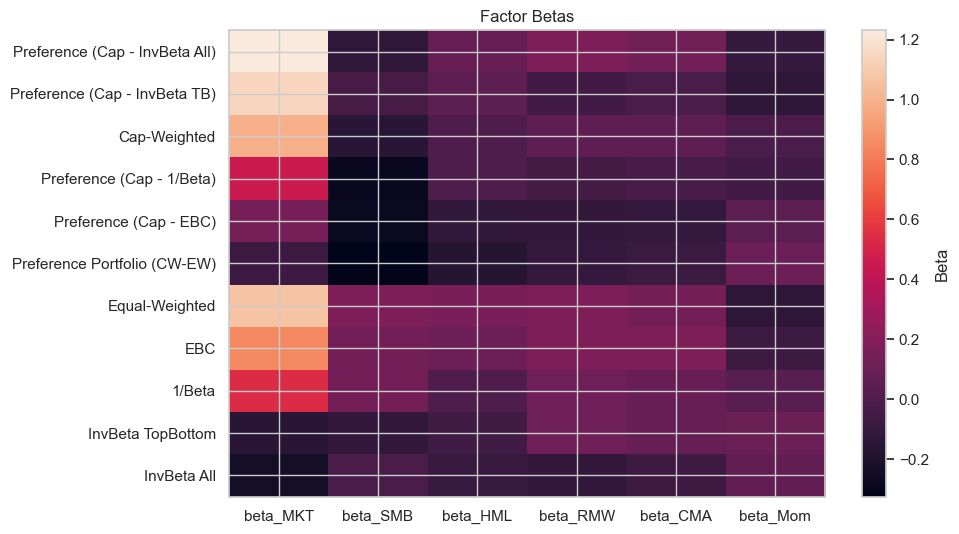

In [93]:
betas = summary[['beta_MKT','beta_SMB','beta_HML','beta_RMW','beta_CMA','beta_Mom']].copy()

plt.figure(figsize=(10, 0.5*len(betas)))
plt.imshow(betas.values, aspect='auto')
plt.xticks(range(betas.shape[1]), betas.columns, rotation=0)
plt.yticks(range(betas.shape[0]), betas.index)
plt.colorbar(label='Beta')
plt.title('Factor Betas')
plt.tight_layout()
plt.show()

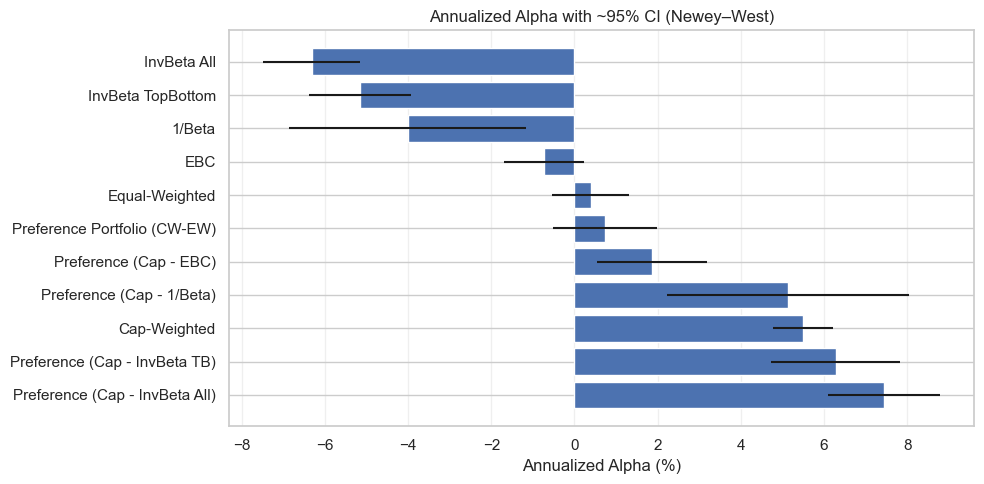

In [94]:
plot_df = summary[['alpha_ann_%','t_alpha(NW)']].copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()
se_ann = (plot_df['alpha_ann_%'].abs() / plot_df['t_alpha(NW)'].abs()).replace([np.inf, -np.inf], np.nan)
err = 1.96 * se_ann

plt.figure(figsize=(10, 5))
ypos = np.arange(len(plot_df))
plt.barh(ypos, plot_df['alpha_ann_%'], xerr=err, align='center')
plt.yticks(ypos, plot_df.index)
plt.xlabel('Annualized Alpha (%)')
plt.title('Annualized Alpha with ~95% CI (Newey–West)')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

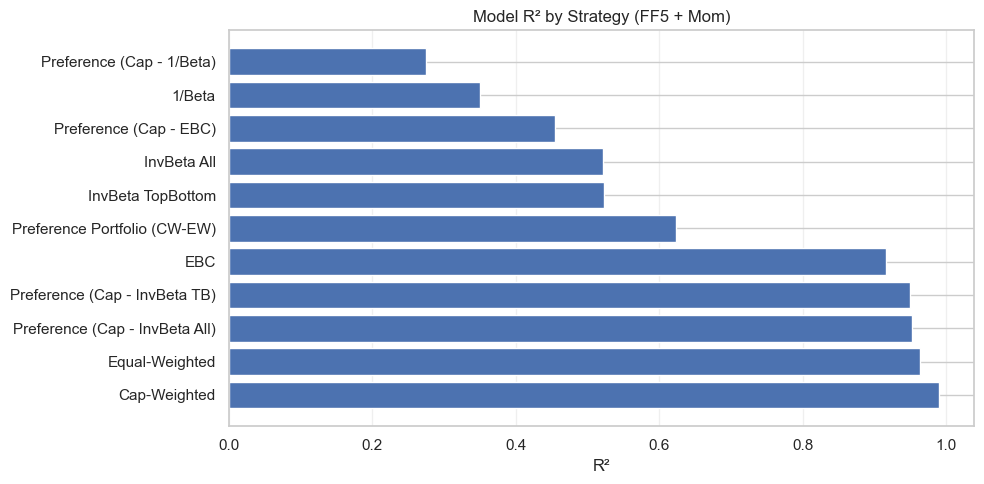

In [95]:
plt.figure(figsize=(10, 5))
order = summary['R2'].sort_values(ascending=False)
plt.barh(range(len(order)), order.values)
plt.yticks(range(len(order)), order.index)
plt.xlabel('R²')
plt.title('Model R² by Strategy (FF5 + Mom)')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [97]:

mkt = (ffm['Mkt-RF'] + ffm['RF']).rename('MKT')

crash_cut = mkt.quantile(0.10)
tag_crash = (mkt <= crash_cut).rename('CRASH')

roll_vol = mkt.rolling(60).std()
hv_cut = roll_vol.quantile(0.90)
tag_highvol = (roll_vol >= hv_cut).rename('HIGHVOL')

cum = (1+mkt).cumprod()
running_max = cum.cummax()
dd = cum / running_max - 1.0
tag_drawdown = (dd <= -0.20).rename('DRAWDOWN20')

regimes = pd.concat([tag_crash, tag_highvol, tag_drawdown], axis=1).reindex(ret.index)
regimes.head()

,CRASH,HIGHVOL,DRAWDOWN20
1963-07-31,False,False,False
1963-08-31,False,False,False
1963-09-30,False,False,False
1963-10-31,False,False,False
1963-11-30,False,False,False


In [98]:
known_crises = [
    ("DotCom",      "2000-03", "2002-10"),
    ("GFC",         "2007-10", "2009-03"),
    ("EuroDebt",    "2011-07", "2012-06"),
    ("ChinaDeval",  "2015-08", "2016-02"),
    ("Volmageddon", "2018-02", "2018-02"),
    ("Q4Selloff",   "2018-10", "2018-12"),
    ("COVID",       "2020-02", "2020-04"),
    ("Bear2022",    "2022-01", "2022-10"),
]

In [99]:
def make_crisis_mask(index, start_ym, end_ym):
    start = pd.Period(start_ym, 'M').to_timestamp('M')
    end   = pd.Period(end_ym,   'M').to_timestamp('M')
    m = (index >= start) & (index <= end)
    return pd.Series(m, index=index)

crisis_cols = {}
for name, s, e in known_crises:
    crisis_cols[name] = make_crisis_mask(ret.index, s, e)

crisis_df = pd.DataFrame(crisis_cols).fillna(False)

crisis_df['CRISIS_KNOWN'] = crisis_df.any(axis=1)

regimes_ext = pd.concat([regimes, crisis_df], axis=1).fillna(False)

regimes_ext['EXTREME_ANY'] = regimes_ext[['CRASH','HIGHVOL','DRAWDOWN20','CRISIS_KNOWN']].any(axis=1)


In [100]:
def perf_stats(r):
    ann = r.mean()*12
    vol = r.std()*np.sqrt(12)
    sharpe = ann/vol if vol>0 else np.nan
    mdd = ( (1+r).cumprod().div((1+r).cumprod().cummax()) - 1 ).min()
    hit = (r>0).mean()
    return pd.Series({'AnnRet':ann, 'AnnVol':vol, 'Sharpe':sharpe, 'MaxDD':mdd, 'HitRatio':hit})

def conditional_table(ret, mask, name):
    sub = ret[mask.fillna(False)]
    out = sub.apply(perf_stats)
    out.columns = pd.MultiIndex.from_product([[name], out.columns])
    return out.T

tab_all = ret.apply(perf_stats).T
tab_all.index = pd.MultiIndex.from_product([['ALL'], tab_all.index])

tab_crash   = conditional_table(ret, regimes_ext['CRASH'], 'CRASH')
tab_hv      = conditional_table(ret, regimes_ext['HIGHVOL'], 'HIGHVOL')
tab_dd20    = conditional_table(ret, regimes_ext['DRAWDOWN20'], 'DRAWDOWN20')
tab_ext_any = conditional_table(ret, regimes_ext['EXTREME_ANY'], 'EXTREME_ANY')

known_tabs = []
for name, *_ in known_crises:
    known_tabs.append(conditional_table(ret, regimes_ext[name], name))
tab_known = pd.concat(known_tabs, axis=0) if known_tabs else pd.DataFrame()

summary_extreme = pd.concat([tab_all, tab_crash, tab_hv, tab_dd20, tab_ext_any, tab_known], axis=0)
summary_extreme = summary_extreme.round(3)
summary_extreme

AnnRet  AnnVol  Sharpe  MaxDD  \
ALL      Cap-Weighted                        0.168   0.149   1.125 -0.410   
         Equal-Weighted                      0.133   0.172   0.772 -0.550   
         Preference Portfolio (CW-EW)        0.035   0.058   0.597 -0.222   
         1/Beta                              0.054   0.142   0.379 -0.576   
         Preference (Cap - 1/Beta)           0.114   0.136   0.839 -0.507   
...                                            ...     ...     ...    ...   
Bear2022 Preference (Cap - InvBeta Opt TB)  -0.090   0.270  -0.334 -0.197   
         InvBeta All                         0.071   0.065   1.092 -0.014   
         InvBeta TopBottom                  -0.041   0.069  -0.587 -0.031   
         Preference (Cap - InvBeta All)     -0.202   0.270  -0.747 -0.229   
         Preference (Cap - InvBeta TB)      -0.090   0.270  -0.334 -0.197   

                                            HitRatio  
ALL      Cap-Weighted                          0.656  
         Equal-Weighted                        0.621  
         Preference Portfolio (CW-EW)          0.585  
         1/Beta                                0.584  
         Preference (Cap - 1/Beta)             0.650  
...                                              ...  
Bear2022 Preference (Cap - InvBeta Opt TB)     0.400  
         InvBeta All                           0.600  
         InvBeta TopBottom                     0.400  
         Preference (Cap - InvBeta All)        0.400  
         Preference (Cap - InvBeta TB)         0.400  

[195 rows x 5 columns]

In [89]:
summary_extreme.to_csv("extreme_siuations.csv")